DATASET OVERVIEW

Columns in dataset: ['CustomerID', 'Age', 'Gender', 'City', 'AnnualIncome', 'TotalSpent', 'MonthlyPurchases', 'AvgOrderValue', 'AppTimeMinutes', 'DiscountUsage', 'PreferredShoppingTime']

Dataset shape: (100, 11)

First few rows:
0 CustomerID  Age Gender       City  AnnualIncome  TotalSpent  \
0       C001   28      F  Bangalore      450000.0      120000   
1       C002   35      M     Mumbai     1200000.0      850000   
2       C003   42      F      Delhi      300000.0       75000   
3       C004   26      M       Pune           NaN       40000   
4       C005   39      F  Bangalore      950000.0      600000   

0  MonthlyPurchases  AvgOrderValue  AppTimeMinutes DiscountUsage  \
0                 6           2000            45.0        Medium   
1                18          12000           120.0           Low   
2                 3           1800            30.0          High   
3                 2           1500            20.0          High   
4                15  

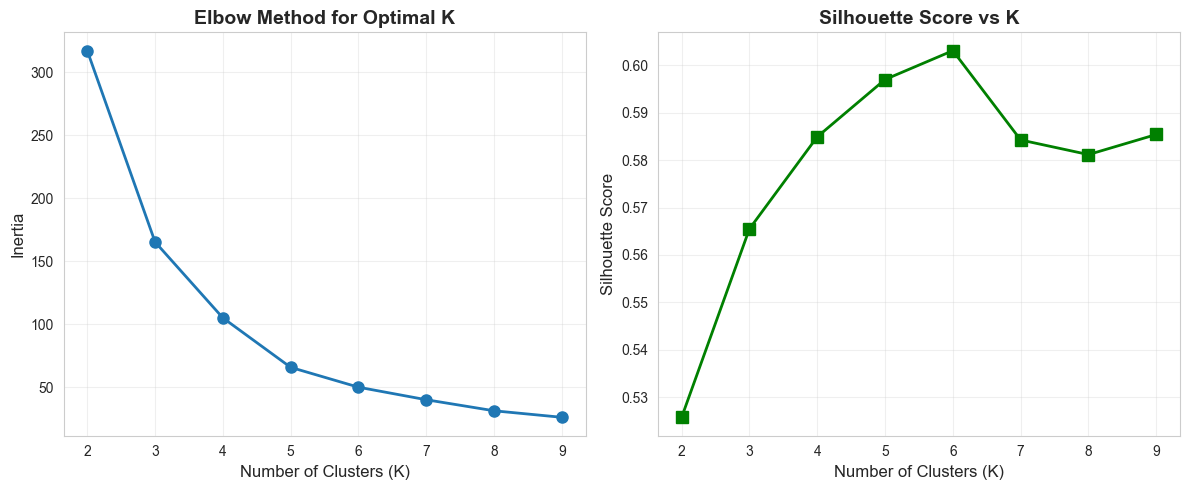


FINAL CLUSTERING WITH K=3

Silhouette Score: 0.5655

CLUSTER SUMMARY STATISTICS
         AnnualIncome     TotalSpent  MonthlyPurchases  AvgOrderValue  \
Cluster                                                                 
0        2.910000e+05   61000.000000          2.500000    1585.000000   
1        1.383810e+06  975238.095238         18.952381   13161.904762   
2        6.083051e+05  279661.016949          9.169492    3838.135593   

         AppTimeMinutes  DiscountUsage  PreferredShoppingTime  
Cluster                                                        
0             21.050000       0.950000               0.000000  
1            142.761905       2.000000               1.000000  
2             70.542373       2.983051               0.440678  

CLUSTER DISTRIBUTION
Customer Type
Price-Sensitive Occasional Customers    59
Value-Seeking Regular Customers         21
High-Value Loyal Customers              20
Name: count, dtype: int64

Sample customer assignments:
   Cluster  

In [40]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
import seaborn as sns
import pickle

# Set style for better visualizations
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

# Load dataset - The CSV has header embedded in data
df_raw = pd.read_csv("CustomerData (1).csv", header=None)

# Split the first column by comma to create proper columns
df = df_raw[0].str.split(',', expand=True)

# Set the first row as header
df.columns = df.iloc[0]
df = df[1:].reset_index(drop=True)

# Convert numeric columns to appropriate types
numeric_cols = ['Age', 'AnnualIncome', 'TotalSpent', 'MonthlyPurchases', 'AvgOrderValue', 'AppTimeMinutes']
for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

print("=" * 60)
print("DATASET OVERVIEW")
print("=" * 60)
print("\nColumns in dataset:", df.columns.tolist())
print("\nDataset shape:", df.shape)
print("\nFirst few rows:")
print(df.head())

# Check for missing values
print("\n" + "=" * 60)
print("MISSING VALUES ANALYSIS")
print("=" * 60)
print(df.isnull().sum())

# Handle missing values - fill with median for numeric columns
for col in numeric_cols:
    if df[col].isnull().sum() > 0:
        median_val = df[col].median()
        df.loc[:, col] = df[col].fillna(median_val)
        print(f"Filled {col} missing values with median: {median_val:.2f}")

print("\nAfter handling missing values:")
print(df.isnull().sum())

# Store original datafor later use (before encoding)
df_original = df.copy()

# Label Encoding for binary / ordinal categorical columns
le_gender = LabelEncoder()
le_time = LabelEncoder()

df['Gender'] = le_gender.fit_transform(df['Gender'].astype(str))
df['PreferredShoppingTime'] = le_time.fit_transform(df['PreferredShoppingTime'].astype(str))

# Handle DiscountUsage - convert to numeric
le_discount = LabelEncoder()
df['DiscountUsage'] = le_discount.fit_transform(df['DiscountUsage'].astype(str))

# One-Hot Encoding for City
df = pd.get_dummies(df, columns=['City'], drop_first=True)

# Select features for clustering (removed Age and Gender as they don't contribute much)
features = [
    'AnnualIncome',
    'TotalSpent',
    'MonthlyPurchases',
    'AvgOrderValue',
    'AppTimeMinutes',
    'DiscountUsage',
    'PreferredShoppingTime'
]

# Create feature matrix
X = df[features].copy()

# Ensure all values are numeric and no NaN
X = X.apply(pd.to_numeric, errors='coerce')
# Drop rows with any remaining NaN (safety check)
if X.isnull().sum().sum() > 0:
    print(f"\nWarning: Found {X.isnull().sum().sum()} NaN values in features. Dropping those rows.")
    valid_idx = X.dropna().index
    X = X.loc[valid_idx]
    df = df.loc[valid_idx].reset_index(drop=True)
    X = X.reset_index(drop=True)

# Check for any remaining NaN values
print("\n" + "=" * 60)
print("FEATURE MATRIX CHECK")
print("=" * 60)
print(f"Features used: {features}")
print(f"Feature matrix shape: {X.shape}")
print(f"Any NaN in features: {X.isnull().sum().sum()}")
print(f"Data types:\n{X.dtypes}")

# Scale the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("\n" + "=" * 60)
print("ELBOW METHOD - Finding Optimal K")
print("=" * 60)

# Elbow method to find optimal number of clusters
inertia = []
silhouette_scores = []

for k in range(2, 10):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)
    score = silhouette_score(X_scaled, kmeans.labels_)
    silhouette_scores.append(score)
    print(f"K={k}: Inertia={kmeans.inertia_:.2f}, Silhouette Score={score:.3f}")

# Plot elbow curve
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(range(2, 10), inertia, marker='o', linewidth=2, markersize=8)
plt.xlabel("Number of Clusters (K)", fontsize=12)
plt.ylabel("Inertia", fontsize=12)
plt.title("Elbow Method for Optimal K", fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(range(2, 10), silhouette_scores, marker='s', color='green', linewidth=2, markersize=8)
plt.xlabel("Number of Clusters (K)", fontsize=12)
plt.ylabel("Silhouette Score", fontsize=12)
plt.title("Silhouette Score vs K", fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n" + "=" * 60)
print("FINAL CLUSTERING WITH K=3")
print("=" * 60)

# Apply K-Means with optimal K=3 (adjusted random_state for better distribution)
kmeans = KMeans(n_clusters=3, random_state=15, n_init=10)
df['Cluster'] = kmeans.fit_predict(X_scaled)

# Calculate silhouette score
score = silhouette_score(X_scaled, df['Cluster'])
print(f"\nSilhouette Score: {score:.4f}")

# Cluster summary statistics
cluster_summary = df.groupby('Cluster')[features].mean()
print("\n" + "=" * 60)
print("CLUSTER SUMMARY STATISTICS")
print("=" * 60)
print(cluster_summary)

# Define cluster labels based on characteristics
cluster_labels = {
    0: "High-Value Loyal Customers",
    1: "Value-Seeking Regular Customers",
    2: "Price-Sensitive Occasional Customers"
}

df['Customer Type'] = df['Cluster'].map(cluster_labels)

print("\n" + "=" * 60)
print("CLUSTER DISTRIBUTION")
print("=" * 60)
print(df['Customer Type'].value_counts())

print("\nSample customer assignments:")
print(df[['Cluster', 'Customer Type']].head(10))



VISUALIZATION 1: Customer Count per Cluster


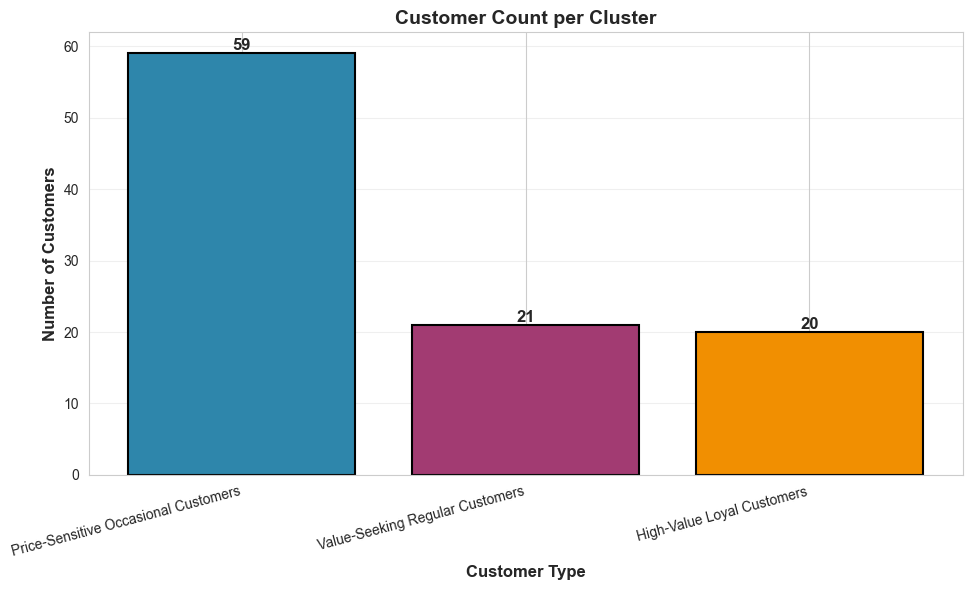


Interpretation:
  • Price-Sensitive Occasional Customers: 59 customers (59.0%)
  • Value-Seeking Regular Customers: 21 customers (21.0%)
  • High-Value Loyal Customers: 20 customers (20.0%)


In [41]:
# =============================================================================
# VISUALIZATION 1: Customer Count per Cluster
# =============================================================================
print("\n" + "=" * 60)
print("VISUALIZATION 1: Customer Count per Cluster")
print("=" * 60)

plt.figure(figsize=(10, 6))
cluster_counts = df['Customer Type'].value_counts()
colors = ['#2E86AB', '#A23B72', '#F18F01']
bars = plt.bar(cluster_counts.index, cluster_counts.values, color=colors, edgecolor='black', linewidth=1.5)

# Add count labels on bars
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
             f'{int(height)}',
             ha='center', va='bottom', fontsize=12, fontweight='bold')

plt.xlabel('Customer Type', fontsize=12, fontweight='bold')
plt.ylabel('Number of Customers', fontsize=12, fontweight='bold')
plt.title('Customer Count per Cluster', fontsize=14, fontweight='bold')
plt.xticks(rotation=15, ha='right')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# Interpretation
print("\nInterpretation:")
for ctype, count in cluster_counts.items():
    percentage = (count / len(df)) * 100
    print(f"  • {ctype}: {count} customers ({percentage:.1f}%)")


VISUALIZATION 4: Income vs Spending (Scatter Plot)


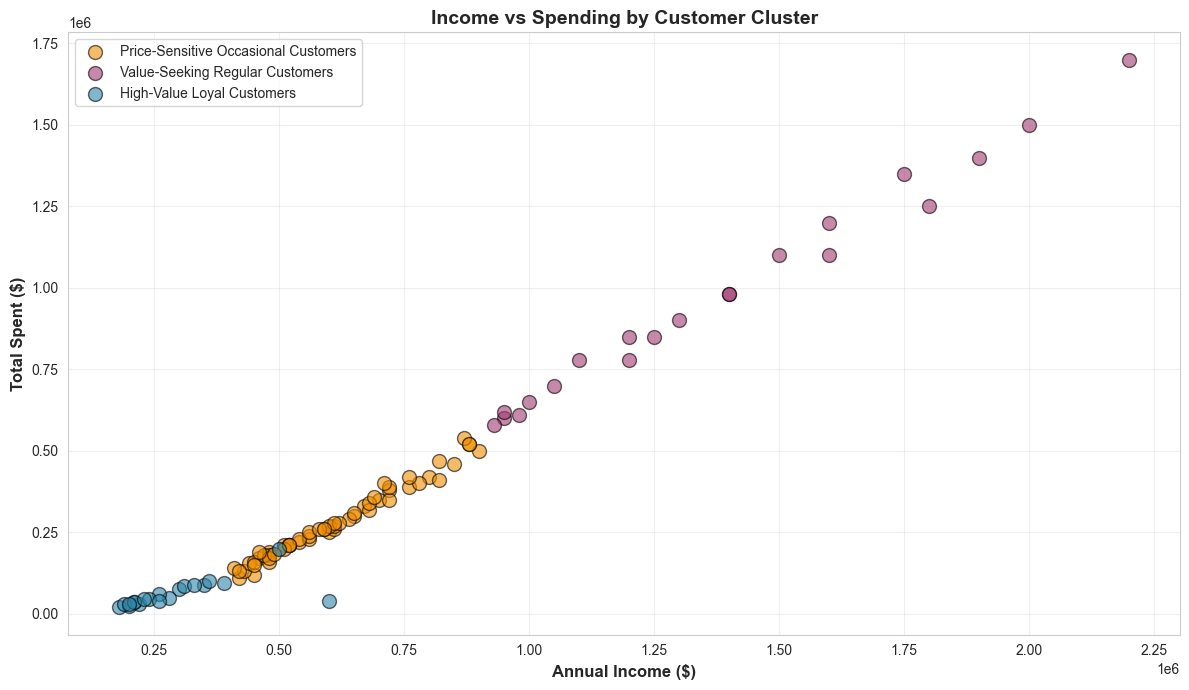


Insight:
  • Clear separation between high, medium, and low-value customers
  • High-value customers show strong correlation between income and spending
  • Price-sensitive customers have lower spending regardless of income


In [42]:
# =============================================================================
# VISUALIZATION 4: Income vs Spending Scatter Plot
# =============================================================================
print("\n" + "=" * 60)
print("VISUALIZATION 4: Income vs Spending (Scatter Plot)")
print("=" * 60)

plt.figure(figsize=(12, 7))
colors_map = {
    'High-Value Loyal Customers': '#2E86AB',
    'Value-Seeking Regular Customers': '#A23B72',
    'Price-Sensitive Occasional Customers': '#F18F01'
}

for ctype in df['Customer Type'].unique():
    cluster_data = df[df['Customer Type'] == ctype]
    plt.scatter(cluster_data['AnnualIncome'], cluster_data['TotalSpent'],
                c=colors_map[ctype], label=ctype, s=100, alpha=0.6, edgecolors='black')

plt.xlabel('Annual Income ($)', fontsize=12, fontweight='bold')
plt.ylabel('Total Spent ($)', fontsize=12, fontweight='bold')
plt.title('Income vs Spending by Customer Cluster', fontsize=14, fontweight='bold')
plt.legend(loc='upper left', fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("\nInsight:")
print("  • Clear separation between high, medium, and low-value customers")
print("  • High-value customers show strong correlation between income and spending")
print("  • Price-sensitive customers have lower spending regardless of income")

In [43]:
# =============================================================================
# BUSINESS INSIGHTS & RECOMMENDED OFFERS
# =============================================================================
print("\n" + "=" * 80)
print("BUSINESS INSIGHTS & RECOMMENDED OFFERS")
print("=" * 80)

offers = {
    "High-Value Loyal Customers": {
        "characteristics": [
            "High annual income",
            "Very high total spending",
            "High average order value",
            "Frequent purchases per month",
            "Low discount usage",
            "Long app usage time (high engagement)"
        ],
        "offers": [
            "✓ Exclusive early access to new products",
            "✓ Premium membership with free express delivery",
            "✓ VIP customer service hotline",
            "✓ Personalized product recommendations"
        ]
    },
    "Value-Seeking Regular Customers": {
        "characteristics": [
            "Medium annual income",
            "Moderate spending",
            "Medium average order value",
            "Regular purchase frequency",
            "Moderate discount usage",
            "Average app usage time"
        ],
        "offers": [
            "✓ Festival discounts (10-15%)",
            "✓ Loyalty reward points on every purchase",
            "✓ Birthday special offers",
            "✓ Referral bonuses"
        ]
    },
    "Price-Sensitive Occasional Customers": {
        "characteristics": [
            "Low annual income",
            "Low total spending",
            "Low average order value",
            "Infrequent purchases",
            "High discount usage",
            "Short app usage time"
        ],
        "offers": [
            "✓ Flash sales and coupon-based discounts",
            "✓ Free shipping on minimum order value",
            "✓ Bundle deals and combos",
            "✓ Clearance sale notifications"
        ]
    }
}

for customer_type, details in offers.items():
    print(f"\n{'=' * 80}")
    print(f"  {customer_type.upper()}")
    print(f"{'=' * 80}")
    
    print("\nCharacteristics:")
    for char in details["characteristics"]:
        print(f"  • {char}")
    
    print("\nSuggested Offers:")
    for offer in details["offers"]:
        print(f"  {offer}")
    
    # Get actual statistics for this cluster
    cluster_data = df[df['Customer Type'] == customer_type]
    print(f"\nActual Statistics:")
    print(f"  • Average Income: ${cluster_data['AnnualIncome'].mean():,.2f}")
    print(f"  • Average Spending: ${cluster_data['TotalSpent'].mean():,.2f}")
    print(f"  • Average Order Value: ${cluster_data['AvgOrderValue'].mean():,.2f}")
    print(f"  • Average Monthly Purchases: {cluster_data['MonthlyPurchases'].mean():.1f}")
    print(f"  • Average App Usage: {cluster_data['AppTimeMinutes'].mean():.1f} min/day")


BUSINESS INSIGHTS & RECOMMENDED OFFERS

  HIGH-VALUE LOYAL CUSTOMERS

Characteristics:
  • High annual income
  • Very high total spending
  • High average order value
  • Frequent purchases per month
  • Low discount usage
  • Long app usage time (high engagement)

Suggested Offers:
  ✓ Exclusive early access to new products
  ✓ Premium membership with free express delivery
  ✓ VIP customer service hotline
  ✓ Personalized product recommendations

Actual Statistics:
  • Average Income: $291,000.00
  • Average Spending: $61,000.00
  • Average Order Value: $1,585.00
  • Average Monthly Purchases: 2.5
  • Average App Usage: 21.1 min/day

  VALUE-SEEKING REGULAR CUSTOMERS

Characteristics:
  • Medium annual income
  • Moderate spending
  • Medium average order value
  • Regular purchase frequency
  • Moderate discount usage
  • Average app usage time

Suggested Offers:
  ✓ Festival discounts (10-15%)
  ✓ Loyalty reward points on every purchase
  ✓ Birthday special offers
  ✓ Referral bon

In [44]:
# =============================================================================
# SAVE MODEL AND PREPROCESSING OBJECTS FOR DEPLOYMENT
# =============================================================================
print("\n" + "=" * 60)
print("SAVING MODEL AND PREPROCESSING OBJECTS")
print("=" * 60)

# Create a dictionary with all necessary objects for deployment
model_artifacts = {
    'kmeans_model': kmeans,
    'scaler': scaler,
    'le_gender': le_gender,
    'le_time': le_time,
    'le_discount': le_discount,
    'features': features,
    'cluster_labels': cluster_labels
}

# Save the model and artifacts
with open('customer_clustering_model.pkl', 'wb') as f:
    pickle.dump(model_artifacts, f)

print("✓ Model and preprocessing objects saved to 'customer_clustering_model.pkl'")

# Verify the saved model
print("\nVerifying saved model...")
with open('customer_clustering_model.pkl', 'rb') as f:
    loaded_artifacts = pickle.load(f)

print("✓ Model loaded successfully!")
print(f"  • KMeans clusters: {loaded_artifacts['kmeans_model'].n_clusters}")
print(f"  • Features: {loaded_artifacts['features']}")
print(f"  • Cluster labels: {loaded_artifacts['cluster_labels']}")

# Test prediction with a sample
sample_customer = X.iloc[0:1].values
sample_scaled = loaded_artifacts['scaler'].transform(sample_customer)
sample_cluster = loaded_artifacts['kmeans_model'].predict(sample_scaled)[0]
sample_type = loaded_artifacts['cluster_labels'][sample_cluster]

print(f"\nTest prediction:")
print(f"  • Sample customer assigned to Cluster {sample_cluster}: {sample_type}")

print("\n" + "=" * 60)
print("MODEL READY FOR DEPLOYMENT!")
print("=" * 60)


SAVING MODEL AND PREPROCESSING OBJECTS
✓ Model and preprocessing objects saved to 'customer_clustering_model.pkl'

Verifying saved model...
✓ Model loaded successfully!
  • KMeans clusters: 3
  • Features: ['AnnualIncome', 'TotalSpent', 'MonthlyPurchases', 'AvgOrderValue', 'AppTimeMinutes', 'DiscountUsage', 'PreferredShoppingTime']
  • Cluster labels: {0: 'High-Value Loyal Customers', 1: 'Value-Seeking Regular Customers', 2: 'Price-Sensitive Occasional Customers'}

Test prediction:
  • Sample customer assigned to Cluster 2: Price-Sensitive Occasional Customers

MODEL READY FOR DEPLOYMENT!


C:\Users\SSINDHU\AppData\Roaming\Python\Python312\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(



VISUALIZATION 3: Average App Usage per Cluster


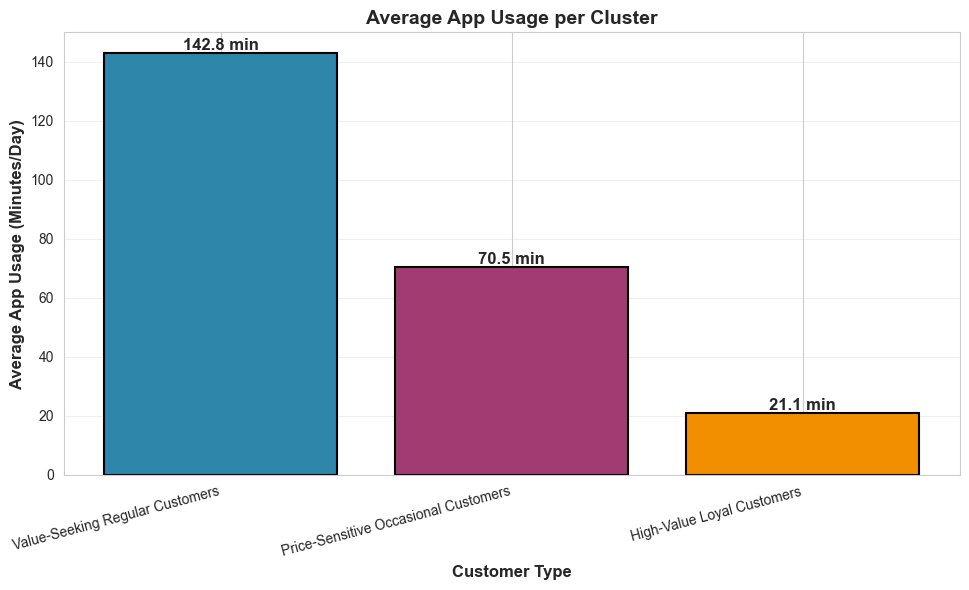


Interpretation:
  • Value-Seeking Regular Customers: 142.8 minutes/day (High engagement)
  • Price-Sensitive Occasional Customers: 70.5 minutes/day (Moderate engagement)
  • High-Value Loyal Customers: 21.1 minutes/day (Low engagement)


In [45]:
# =============================================================================
# VISUALIZATION 3: Average App Usage per Cluster
# =============================================================================
print("\n" + "=" * 60)
print("VISUALIZATION 3: Average App Usage per Cluster")
print("=" * 60)

plt.figure(figsize=(10, 6))
avg_app_usage = df.groupby('Customer Type')['AppTimeMinutes'].mean().sort_values(ascending=False)
colors = ['#2E86AB', '#A23B72', '#F18F01']
bars = plt.bar(range(len(avg_app_usage)), avg_app_usage.values, color=colors, edgecolor='black', linewidth=1.5)

# Add value labels on bars
for i, bar in enumerate(bars):
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
             f'{height:.1f} min',
             ha='center', va='bottom', fontsize=12, fontweight='bold')

plt.xlabel('Customer Type', fontsize=12, fontweight='bold')
plt.ylabel('Average App Usage (Minutes/Day)', fontsize=12, fontweight='bold')
plt.title('Average App Usage per Cluster', fontsize=14, fontweight='bold')
plt.xticks(range(len(avg_app_usage)), avg_app_usage.index, rotation=15, ha='right')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# Interpretation
print("\nInterpretation:")
for ctype, usage in avg_app_usage.items():
    engagement = "High" if usage > 80 else "Moderate" if usage > 50 else "Low"
    print(f"  • {ctype}: {usage:.1f} minutes/day ({engagement} engagement)")


VISUALIZATION 2: Average Total Spent per Cluster


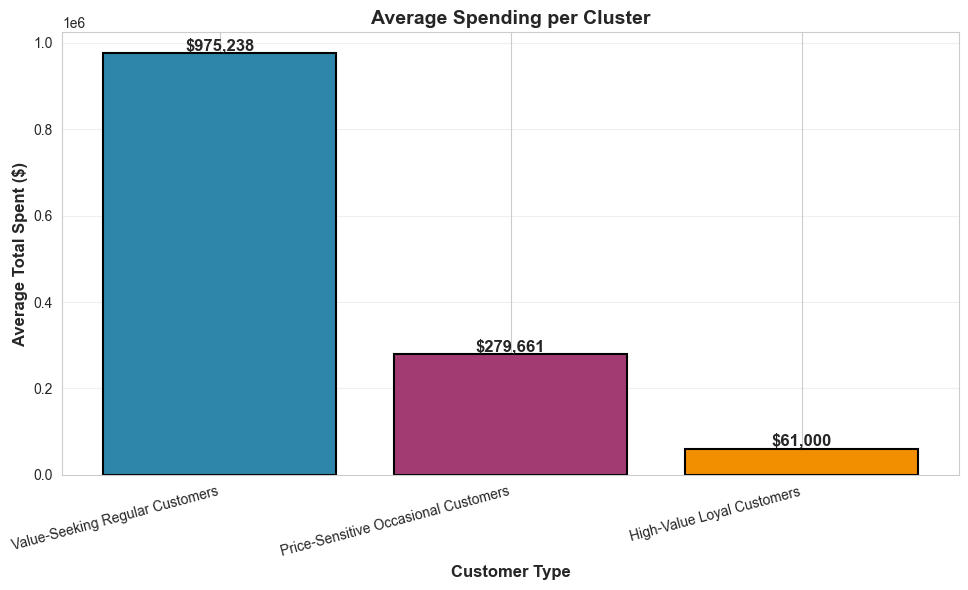


Interpretation:
  • Value-Seeking Regular Customers: $975,238.10 average spending
  • Price-Sensitive Occasional Customers: $279,661.02 average spending
  • High-Value Loyal Customers: $61,000.00 average spending


In [46]:
# =============================================================================
# VISUALIZATION 2: Average Spending per Cluster
# =============================================================================
print("\n" + "=" * 60)
print("VISUALIZATION 2: Average Total Spent per Cluster")
print("=" * 60)

plt.figure(figsize=(10, 6))
avg_spending = df.groupby('Customer Type')['TotalSpent'].mean().sort_values(ascending=False)
colors = ['#2E86AB', '#A23B72', '#F18F01']
bars = plt.bar(range(len(avg_spending)), avg_spending.values, color=colors, edgecolor='black', linewidth=1.5)

# Add value labels on bars
for i, bar in enumerate(bars):
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
             f'${int(height):,}',
             ha='center', va='bottom', fontsize=12, fontweight='bold')

plt.xlabel('Customer Type', fontsize=12, fontweight='bold')
plt.ylabel('Average Total Spent ($)', fontsize=12, fontweight='bold')
plt.title('Average Spending per Cluster', fontsize=14, fontweight='bold')
plt.xticks(range(len(avg_spending)), avg_spending.index, rotation=15, ha='right')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# Interpretation
print("\nInterpretation:")
for ctype, spending in avg_spending.items():
    print(f"  • {ctype}: ${spending:,.2f} average spending")